# **Final model for the project**

In [ ]:
# install package and create a virtual environment
!python3 -m venv sailing-env
!source sailing-env/bin/activate
!pip install -r requirements.txt

In [ ]:
# to avoid actualization problem with others documents 
%load_ext autoreload
%autoreload 2

In [ ]:
#importations
from src.utils.agent_utils import save_dqn_agent
import sys
import os
import numpy as np
import random
from collections import deque
import pickle
import math
import time

# Add the src directory to the path
sys.path.append(os.path.abspath('../src'))
sys.path.append(os.path.abspath('..'))

# Import the BaseAgent class
from src.agents.base_agent import BaseAgent

from src.env_sailing import SailingEnv
from src.wind_scenarios import get_wind_scenario

## **0) - Method**

For this project, I used a deep reinforcement learning algorithm: DQN (Deep Q-Network). To do this, I started by coding an MLP in numpy (to be compatible with codabench). Then I added modifications to improve the results. In particular, I implemented double DQN (using two neural networks instead of one) to reduce the overestimation of the Q values. This concept is introduced in the paper "Deep Reinforcement Learning with Double Q-learning" by Hado van Hasselt, Arthur Guez, and David Silver.Furthermore, I used soft target network updates instead of a classic update every n steps to smooth out the updates and avoid abrupt changes. Additionally, as in the deep reinforcement learning lab in class, I used a buffer to store the last c values ​​and draw a sample of b values ​​from this buffer. This concept is based on the paper: "PRIORITIZED EXPERIENCE REPLAY" written by Tom Schaul, John Quan, Ioannis Antonoglou and David Silver. Finaly, in the MLP, I used Huber loss instead of MSE (which I had used in my earlier versions) to provide better robustness against large errors.

Regarding the method used to process the data and improve the results, the most significant impact was the creation of features from the information provided in "observation" and the creation of rewards. For the features, we have several, but we encountered issues with the over-reliance on certain information (too many features for the same piece of information). We simply kept the final version. For the rewards, we retained the code for some tested rewards that were not included in the final reward. Finally, we also added randomness to the wind during the training phase to obtain better results.

Regarding my methodology, I began by establishing an initial result using q learning and the reward system, as suggested in the instructions. Then I created my DQN model with these rewards, which I recalibrated. Next, I added features and made further adjustments as I went along to improve the results. I also conducted numerous tests on hyperparameter variations.

## **1) - Creation of the model**

In [ ]:
class NeuralNetwork:
    """Creation of a MLP for the DQN agent"""
    def __init__(self, input_size=44, hidden_size_1=128, hidden_size_2 = 128, output_size=9 ,learning_rate=0.001):
        """
        Initiate the MLP

        Parameters : 

        input_size : int 
        Number of input features

        hidden_size_1 : int
        Number of neurons in the first hidden layer

        hidden_size_2 : int
        Number of neurons in the last hidden layer

        output_size : int
        Number of directions 

        learning_rate : float
        Learning rate for the descent gradient
        """
        super().__init__()
        self.np_random = np.random.default_rng()

        # Learning parameters
        self.learning_rate = learning_rate

        # Linear parameters 
        self.W1 = np.random.randn(input_size, hidden_size_1) * np.sqrt(2./input_size) #use He initialization because we use a ReLU after
        self.b1 = np.zeros((1, hidden_size_1))
        self.W2 = np.random.randn(hidden_size_1, hidden_size_2) * np.sqrt(2./hidden_size_1)
        self.b2 = np.zeros((1, hidden_size_2))  
        self.W3 = np.random.randn(hidden_size_2, output_size) * np.sqrt(2./hidden_size_2)
        self.b3 = np.zeros((1, output_size))

    def forward(self, X):
        """forward pass through the neural network
        
        Parameter : 
        X : np.ndarray
        Input batch 

        Return : 
        l3 : np.ndarray
        Predicted Q values for each action
        """

        #store X for backward
        self.X = np.array(X)

        #forward pass
        self.l1 = np.dot(X, self.W1) + self.b1 #linear
        self.relu1 = np.maximum(0, self.l1) #relu
        self.l2 = np.dot(self.relu1, self.W2) + self.b2 #linear
        self.relu2 = np.maximum(0, self.l2) #relu
        self.l3 = np.dot(self.relu2, self.W3) + self.b3 #linear
        return self.l3

    def backward(self, y_pred, y_true, weights=None):
        """backpropagation and update weights
        
        Parameters : 
        y_pred : np.ndarray
        Current Q value prediction

        y_true : np.ndarray
        Target Q value
        """

        #size of the batch
        batch_size = y_pred.shape[0]

        #use of huber loss
        delta = y_pred - y_true #error
        if weights is not None:
            delta *= weights[:, None] #prioritized replay weights 
        huber_delta = 1.0
        loss_grad = np.where(np.abs(delta) < huber_delta,delta,huber_delta * np.sign(delta))

        #classical backward
        dl3 = loss_grad / batch_size 
        dW3 = np.dot(self.relu2.T, dl3)
        db3 = np.sum(dl3, axis=0, keepdims=True)

        drelu2 = np.dot(dl3, self.W3.T) #relu derivate
        dl2 = drelu2 * (self.l2 > 0)
        dW2 = np.dot(self.relu1.T, dl2)
        db2 = np.sum(dl2, axis=0, keepdims=True)

        drelu1 = np.dot(dl2, self.W2.T)
        dl1 = drelu1 * (self.l1 > 0)
        dW1 = np.dot(self.X.T, dl1)
        db1 = np.sum(dl1, axis=0, keepdims=True)

        #clip to avoid too large values
        max_grad = 10.0
        for grad in [dW1, db1, dW2, db2, dW3, db3]:
            np.clip(grad, -max_grad, max_grad, out=grad)

        #gradient descent 
        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1


    def copy_weights(self):
        """copy weights 
        
        Returns:
        dict 
        A copy of biases and weights
        """
        return {
            'W1': self.W1.copy(), 'b1': self.b1.copy(),
            'W2': self.W2.copy(), 'b2': self.b2.copy(),
            'W3': self.W3.copy(), 'b3': self.b3.copy()
        }  

    def update_weights(self, weights):
        """update weight to other values
        
        Parameters : 
        weights : dict
        New weights and biases
        
        """
        self.W1 = weights['W1'].copy()
        self.b1 = weights['b1'].copy()
        self.W2 = weights['W2'].copy()
        self.b2 = weights['b2'].copy()
        self.W3 = weights['W3'].copy()
        self.b3 = weights['b3'].copy() 

In [ ]:
class DQNAgent(BaseAgent):
    """The DQN agent
    
    Use Double DQN, Prioritized Experience Replay and Epsilon Greedy exploration
    
    """
    def __init__(self, hidden_size_1=128, hidden_size_2=128, memory_buffer = 100000, learning_rate=0.001, discount_factor=0.9, exploration_rate=0.1):
        """
        Initiates the agent

        Parameters : 
        
        hidden_size_1 : int
        Number of neurons in the first hidden layer

        hidden_size_2 : int
        Number of neurons in the last hidden layer

        memory_buffer : int 
        Maximum size for the buffer

        learning_rate : float
        Learning rate for the neural network

        discount_factor : float
        discount factor for distance reward as suggest in the instruction (Potential-based shaping)

        exploration_rate : float
        beginning epsilon for epsilon greedy exploration
        """
        super().__init__()
        
        # Random
        self.np_random = np.random.default_rng()
        self.buffer_random = random.Random()        

        # Learning parameters
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate

        #MLPs
        self.policy_net = NeuralNetwork(22, hidden_size_1, hidden_size_2, 9, self.learning_rate) #to choose actions
        self.target_net = NeuralNetwork(22, hidden_size_1, hidden_size_2, 9, self.learning_rate) #to calcule targets

        #to initiate both neural networks with same weights
        self.update_weights_target()

        #to store with memory (replay buffer)
        self.buffer = deque(maxlen=memory_buffer)
        self.priorities = deque(maxlen=memory_buffer) 
        self.priority_alpha = 0.6 #control the importance of priority
        self.beta = 0.4 #to correct biaise
        self.beta_increment = 1e-4 #increase of beta

    def get_features(self, observation, training=True):
        """create (22) features from observations
        
        Parameters : 
        observation : np.ndarray
        observation 

        training : bool
        True if training

        Returns : 
        np.ndarray
        Feature vector of size 22    
        """

        x, y = observation[0], observation[1] #position
        vx, vy = observation[2], observation[3] #speed
        wx, wy = observation[4], observation[5] #wind
        flattened_world = observation[6+32768:].reshape(128,128) #world map

        if training :
            #randomize wind in training (for generalization)
            theta = self.np_random.uniform(-np.pi/2, np.pi/2) 
            scale = self.np_random.uniform(0.7, 1.3)
            wx, wy = wx * scale, wy * scale
            wx_rot = wx * np.cos(theta) - wy * np.sin(theta)
            wy_rot = wx * np.sin(theta) + wy * np.cos(theta)
            wx, wy = wx_rot, wy_rot

        #clip information (avoid extreme values)
        vx = np.clip(vx, -5, 5) / 5
        vy = np.clip(vy, -5, 5) / 5
        wx = np.clip(wx, -5, 5) / 5
        wy = np.clip(wy, -5, 5) / 5

        #store features
        features = []

        #feature with local speed and position
        v = np.sqrt(vx**2+vy**2) #norm 2 of the speed vector 
        features.extend([x/128, y/128, vx, vy, v])

        #feature with goal
        goal = [64, 127]
        dx, dy = goal[0] - x, goal[1] - y
        dist_to_goal = np.sqrt(dx**2 + dy**2)
        norm = np.sqrt(128**2 + 128**2)
        angle_to_goal = np.arctan2(dy, dx)
        features.extend([dist_to_goal/norm, np.cos(angle_to_goal), np.sin(angle_to_goal)])

        #vmg (velocity made good)
        if v>0.05:
            boat_angle = np.arctan2(vy, vx)
            vmg = v * np.cos(boat_angle - angle_to_goal)
        else :
            vmg = v
            boat_angle = angle_to_goal
        features.append(vmg)

        #feature angle with wind
        wind_angle = np.arctan2(wy, wx)
        relative_wind = abs((wind_angle - boat_angle + np.pi) % (2*np.pi) - np.pi)
        wind_goal_angle = abs((wind_angle - angle_to_goal + np.pi) % (2*np.pi) - np.pi)
        features.extend([np.cos(relative_wind), np.sin(relative_wind),np.cos(wind_goal_angle), np.sin(wind_goal_angle), np.sqrt(wx**2 + wy**2)])

        #feature of danger
        direction = [(0,1), (1,1), (1,0), (1,-1), (0,-1), (-1,-1), (-1,0), (-1,1)]
        #we choose a direction and create a feature of danger to the island
        for direction_x, direction_y in direction: 
            danger = 0
            for distance in range(1,25):
                new_x = int(x + direction_x*distance)
                new_y = int(y + direction_y*distance)
                if 0 <= new_x < 128 and 0<= new_y < 128:
                    if flattened_world[new_x,new_y] == 1:
                        danger = (25 - distance)/25 
                        break
            features.append(danger)
        
        return np.array(features)

    def act(self, observation, training=True):
        """Choose an action using epsilon-greedy policy.
        
        Parameters : 
        observation : np.ndarray
        observation 

        training : bool
        True if training

        returns : 
        int
        Selected action index
        """
        state = self.get_features(observation, training).reshape(1, -1) #feature extraction
        # Epsilon-greedy action selection
        if self.np_random.random() < self.exploration_rate: 
            return self.np_random.integers(0, 9)
        else:
            q_values = self.policy_net.forward(state)
            return int(np.argmax(q_values))

    def learn(self, observation, action, reward, next_observation, batch_size, done):
        """Update dqn based on observed transition.
        The double DQN with proportional prioritization of the paper "PRIORITIZED EXPERIENCE REPLAY" is applied

        Parameters : 
        observation : np.ndarray
        observation

        action : int
        action done

        reward : float
        reward received

        next_observation : np.ndarray
        next observation

        batch_size : int
        batch size

        done : bool
        True if the episode is over

        """
        
        #features extractions
        state = self.get_features(observation, training=False)
        next_state = self.get_features(next_observation, training=False)

        #store in buffer
        self.buffer.append((state, action, reward, next_state, done))

        #initialization of the priorities
        if len(self.priorities) > 0:
            max_priority = max(self.priorities)
        else :
            max_priority = 1

        #add priority
        self.priorities.append(max_priority)

        #if buffer too small we wait for more informations
        if len(self.buffer) < batch_size:
            return

        #calcule of the probability of sampling transition as in the paper 
        priorities = np.array(self.priorities, dtype=np.float32)
        probs = priorities ** self.priority_alpha
        probs /= probs.sum()

        #choose of batch
        indices = self.np_random.choice(len(self.buffer), batch_size, p=probs, replace=False)
        batch = [self.buffer[i] for i in indices]

        #get informations of the batch
        states, actions, rewards, next_states, dones = zip(*batch)
        states = np.array(states)
        next_states = np.array(next_states)
        rewards = np.array(rewards)
        dones = np.array(dones)
        actions = np.array(actions)

        #importance sampling weights as in the paper 
        weights = (len(self.buffer) * probs[indices]) ** (-self.beta)
        weights /= weights.max()

        #forward pass to get q
        current_q = self.policy_net.forward(states)
        next_q_target = self.target_net.forward(next_states)
        next_q_policy = self.policy_net.forward(next_states)

        #copy q for target
        targets = current_q.copy()

        #initilize td errors
        td_errors = np.zeros(batch_size)

        for i in range(batch_size):

            #calcul target 
            target = rewards[i]
            if not dones[i]:
                best_action = np.argmax(next_q_policy[i])
                target += self.discount_factor * next_q_target[i, best_action]

            #calcul td error
            td_error = target - current_q[i, actions[i]]
            td_errors[i] = td_error

            #update target 
            targets[i, actions[i]] = current_q[i, actions[i]] + weights[i] * td_error

        #backpropagation
        self.policy_net.forward(states)
        self.policy_net.backward(current_q, targets, weights)

        #avoid nul priorities
        for idx, td in zip(indices, td_errors):
            self.priorities[idx] = abs(td) + 1e-6
            
    def reset(self):
        """Reset the agent for a new episode."""
        # Nothing to reset
        pass
        
    def seed(self, seed=None):
        """Set the random seed.
        
        Parameters :
        seed : int or None
        Value of the seed
        """
        self.np_random = np.random.default_rng(seed)
        self.buffer_random = random.Random(seed)
        self.policy_net.rng = np.random.default_rng(seed)
        self.target_net.rng = np.random.default_rng(seed) 
        
    def save(self, path):
        """Save the weights to a file.
        
        Parameters :
        path : str
        File path
        """
        with open(path, 'wb') as f:
            pickle.dump(self.policy_net.copy_weights(), f)
            
    def load(self, path):
        """Load the weights from a file.
        
        Parameters :
        path : str
        File path
        
        """
        with open(path, 'rb') as f:
            self.policy_net.update_weights(pickle.load(f))
            self.update_weights_target()
    
    def update_weights_target(self):
        """put the weights of policy in target"""
        self.target_net.update_weights(self.policy_net.copy_weights())

    def soft_update(self, tau=0.005):
        """update weights with a tau
        We use that to avoid a direct update in trainign loops

        Parameters :
        tau : float
        Parameter to control soft update
        """
        for attr in ['W1','b1','W2','b2','W3','b3']:
            target_param = getattr(self.target_net, attr)
            policy_param = getattr(self.policy_net, attr)

            updated = tau * policy_param + (1 - tau) * target_param
            setattr(self.target_net, attr, updated) 

## **2) - Training of the model**

In [ ]:
#training

#initilization
dqn_agent = DQNAgent(hidden_size_1=64, hidden_size_2=64, memory_buffer = 25000, learning_rate=0.0005, discount_factor=0.97, exploration_rate=1)
max_steps = 500

#seed
np.random.seed(42)
dqn_agent.seed(42)

#scenarios for training
scenarios = ['training_1', 'training_2', 'training_3']

#hyperparameters
num_episodes = 5200
batch_size = 64
target_update_freq = 100

#to control performances
rewards_history = []
steps_history = []
success_history = []

best_avg_steps = 500
best_success = 0

#to control epsilon evolution (for epsilon greedy)
eps_start = 1.0
eps_end = 0.03
eps_decay = 1000

start_time = time.time()
print(f"Starting full training with {num_episodes} episodes across 3 scenarios...")

#training loops
for episode in range(num_episodes):

    #scenario use
    episode_action_counts = np.zeros(9)
    if episode < 1000:
        scenario = 'training_1'
    elif episode < 2000:
        scenario = scenarios[np.random.randint(0, 2)]
    else:
        scenario = scenarios[np.random.randint(0, 3)]

    #creation of the environment  
    env = SailingEnv(**get_wind_scenario(scenario))
    goal = env.goal_position.copy()

    #reset    
    observation, info = env.reset(seed=episode)

    #initialization
    prev_dist = np.linalg.norm(info['position'] - goal)
    total_reward = 0
    previous_action = None

    #control max step
    if episode < 1200:
        current_max_steps = 500
    elif episode < 2200:
        current_max_steps = 300
    elif episode < 3200:
        current_max_steps = 200
    elif episode < 4000:
        current_max_steps = 140
    elif episode < 4500:
        current_max_steps = 120
    else:
        current_max_steps = 105

    #each episode
    for step in range(current_max_steps):

        #choose action
        action = dqn_agent.act(observation)
        episode_action_counts[action] += 1
        next_observation, reward, done, truncated, info = env.step(action)
        
        #Creation of Rewards 
        # (Some are used, others have been tested and are left in the code but are not used in the final (most efficient) model.) 

        #VMG reward (as in the get feature)
        curr_speed = math.sqrt((info['velocity'][0])**2 + (info['velocity'][1])**2 )
        curr_angle_boat = math.atan2(info['velocity'][1], info['velocity'][0])
        curr_angle_to_goal = math.atan2(goal[1] - info['position'][1], goal[0] - info['position'][0])
        theta = curr_angle_boat - curr_angle_to_goal
        vmg_reward = curr_speed * math.cos(theta)

        #angle wind reward 
        curr_angle_wind = math.atan2(info['wind'][1], info['wind'][0])
        if curr_speed > 0.1:
            curr_angle_boat = math.atan2(info['velocity'][1], info['velocity'][0])
        else :
            curr_angle_boat = curr_angle_wind

        curr_angle = abs(math.degrees(curr_angle_wind - curr_angle_boat))
        if curr_angle > 180 :
            curr_angle = 360 - curr_angle
        if curr_angle < 40:
            wind_reward = -3.0 * (1 - curr_angle / 45)
        elif curr_angle < 60:
            wind_reward = -1.5 + (curr_angle - 45) * (1.0 / 15) 
        elif curr_angle < 75:
            wind_reward = -0.5 + (curr_angle - 60) * (1.0 / 15)
        elif curr_angle < 100:
            center = 87.5
            deviation = abs(curr_angle - center)
            wind_reward = 2.0 - (deviation / 12.5) * 0.5
        elif curr_angle < 140:
            wind_reward = 1.5 - (curr_angle - 100) * (0.3 / 40)
        elif curr_angle < 160:
            wind_reward = 1.2 - (curr_angle - 140) * (0.9 / 25)
        else:
            wind_reward = 0.3 - (curr_angle - 165) * (0.5 / 15) 
        
        #speed reward 
        speed_reward = curr_speed

        #time reward
        time_reward = -0.2

        #change action reward 
        action_reward = 0
        if previous_action != None and action != previous_action :
            action_reward = -0.05

        #distance reward
        curr_dist = np.linalg.norm(info['position'] - goal) 
        distance_reward = (prev_dist - dqn_agent.discount_factor*curr_dist)*5

        #distance to goal reward
        distance_to_goal_reward = -0.3 * (1.0 - curr_dist / 180.0)

        #reward
        shaped_reward = (
            2.5 * reward +        
            0.6 * distance_reward + 
            6.0 * vmg_reward +       
            -0.22                
        )

        #adds a bonus based on speed
        if done and not info.get('is_stuck', False):
            time_bonus = (max_steps - step)*1.5
            shaped_reward += time_bonus

        #penality for stuck
        if info.get('is_stuck', False):
            shaped_reward = -200.0
        prev_dist = curr_dist
        
        #learn with this reward
        dqn_agent.learn(observation, action, shaped_reward, next_observation, batch_size, done)

        #updates
        observation = next_observation
        previous_action = action
        total_reward += reward

        #update target 
        if step % 5 == 0:
            dqn_agent.soft_update(tau=0.005)

        #break if episode finished
        if done or truncated:
            break

    #updates 
    rewards_history.append(total_reward)
    steps_history.append(step + 1)
    is_victory = done and not info.get('is_stuck', False)
    success_history.append(is_victory)

    dqn_agent.beta = min(1.0, dqn_agent.beta + dqn_agent.beta_increment)
    dqn_agent.exploration_rate = eps_end + (eps_start - eps_end) * np.exp(-episode / eps_decay)

    #learning rate decrease
    if episode == 1000:
        dqn_agent.policy_net.learning_rate = 0.0005
        dqn_agent.target_net.learning_rate = 0.0005
    elif episode == 2000:
        dqn_agent.policy_net.learning_rate = 0.0002
        dqn_agent.target_net.learning_rate = 0.0002
    elif episode == 3000:
        dqn_agent.policy_net.learning_rate = 0.0001
        dqn_agent.target_net.learning_rate = 0.0001
    elif episode == 4200:
        dqn_agent.policy_net.learning_rate = 0.00005
        dqn_agent.target_net.learning_rate = 0.00005

    
    #prints 
    # We used AI to help us generate nice prints of the training and to observe how our model behaved during training.
    #(a first version was made without AI and the AI was use tu upgrade)
    if (episode + 1) % 100 == 0:
        recent = success_history[-100:]
        recent_steps = steps_history[-100:]
        recent_rewards = rewards_history[-100:]
        success_rate = sum(recent) / len(recent)
        avg_steps = sum(recent_steps) / len(recent_steps)
        print(f"\n{'='*70}")
        print(f"Episode {episode+1}/{num_episodes}")
        print(f"{'='*70}")
        print(f"Success rate (last 100): {success_rate*100:.1f}%")
        print(f"Avg steps: {avg_steps:.1f}")
        print(f"Exploration rate: {dqn_agent.exploration_rate:.4f}")
        fast_runs = sum(1 for s in recent_steps if s < 60)
        medium_runs = sum(1 for s in recent_steps if 60 <= s < 100)
        slow_runs = sum(1 for s in recent_steps if s >= 100)
        print("Step distribution:")
        print(f"  Fast (<60):     {fast_runs:2d}% | {'█'*int(fast_runs/2)}")
        print(f"  Medium (60-100): {medium_runs:2d}% | {'█'*int(medium_runs/2)}")
        print(f"  Slow (100+):     {slow_runs:2d}% | {'█'*int(slow_runs/2)}")
        sorted_steps = sorted(recent_steps)
        p10 = sorted_steps[10]
        p25 = sorted_steps[25]
        p50 = sorted_steps[50]
        p75 = sorted_steps[75]
        p90 = sorted_steps[90]
        print("Step percentiles:")
        print(f"  Best 10%: {p10:3.0f} | Top 25%: {p25:3.0f} | Median: {p50:3.0f} | P75: {p75:3.0f} | Worst 10%: {p90:3.0f}")
        if len(dqn_agent.buffer) > 100:
            sample_indices = np.random.choice(len(dqn_agent.buffer), min(5, len(dqn_agent.buffer)), replace=False)
            sample_states = [dqn_agent.buffer[i][0] for i in sample_indices]
            sample_states = np.array(sample_states)
            q_values = dqn_agent.policy_net.forward(sample_states)
            print("Q-value stats (policy net):")
            print(f"  Mean: {q_values.mean():6.1f} | Std: {q_values.std():5.1f}")
            print(f"  Max:  {q_values.max():6.1f} | Min: {q_values.min():6.1f}")
        action_probs = episode_action_counts / (episode_action_counts.sum() + 1e-8)
        action_entropy = -np.sum(action_probs * np.log(action_probs + 1e-8))
        
        print("Action distribution (last 100 eps):")
        for i, prob in enumerate(action_probs):
            bar = '█' * int(prob * 50)
            print(f"  Action {i}: {prob:5.2f} | {bar}")
        
        print(f"Action entropy: {action_entropy:.3f}")
        
        accumulated_actions = np.zeros(9)
        print(f"\nLearning rate: {dqn_agent.policy_net.learning_rate:.6f}")
        print(f"Beta (PER): {dqn_agent.beta:.3f}")
        print(f"Current max_steps: {current_max_steps}")
        if success_rate >= 0.95 and avg_steps < best_avg_steps:
            best_avg_steps = avg_steps
            dqn_agent.save("best_sailing_model_test_1.pkl")
            print("✅ SAVED NEW BEST MODEL")
            print(f"   Success: {success_rate*100:.1f}% | Avg steps: {avg_steps:.1f}")

training_time = time.time() - start_time
success_rate = sum(success_history) / len(success_history) * 100
print(f"\nTraining completed in {training_time:.1f} seconds!")
print(f"Overall success rate: {success_rate:.1f}%")

Starting full training with 5200 episodes across 3 scenarios...

Episode 100/5200
Success rate (last 100): 0.0%
Avg steps: 277.8
Exploration rate: 0.9086
Step distribution:
  Fast (<60):      7% | ███
  Medium (60-100):  3% | █
  Slow (100+):     90% | █████████████████████████████████████████████
Step percentiles:
  Best 10%: 100 | Top 25%: 119 | Median: 181 | P75: 500 | Worst 10%: 500
Q-value stats (policy net):
  Mean:  313.7 | Std:  43.1
  Max:   373.6 | Min:  232.9
Action distribution (last 100 eps):
  Action 0:  0.12 | ██████
  Action 1:  0.19 | █████████
  Action 2:  0.10 | ████
  Action 3:  0.10 | █████
  Action 4:  0.06 | ███
  Action 5:  0.10 | ████
  Action 6:  0.09 | ████
  Action 7:  0.12 | ██████
  Action 8:  0.12 | ██████
Action entropy: 2.154

Learning rate: 0.000500
Beta (PER): 0.410
Current max_steps: 500

Episode 200/5200
Success rate (last 100): 0.0%
Avg steps: 175.6
Exploration rate: 0.8250
Step distribution:
  Fast (<60):     22% | ███████████
  Medium (60-100): 1

In [6]:
dqn_agent.save("last_sailing_model_opti_test_1.pkl")
print("Saved the last model")

Saved the last model


## **3) Visualisation of the training**

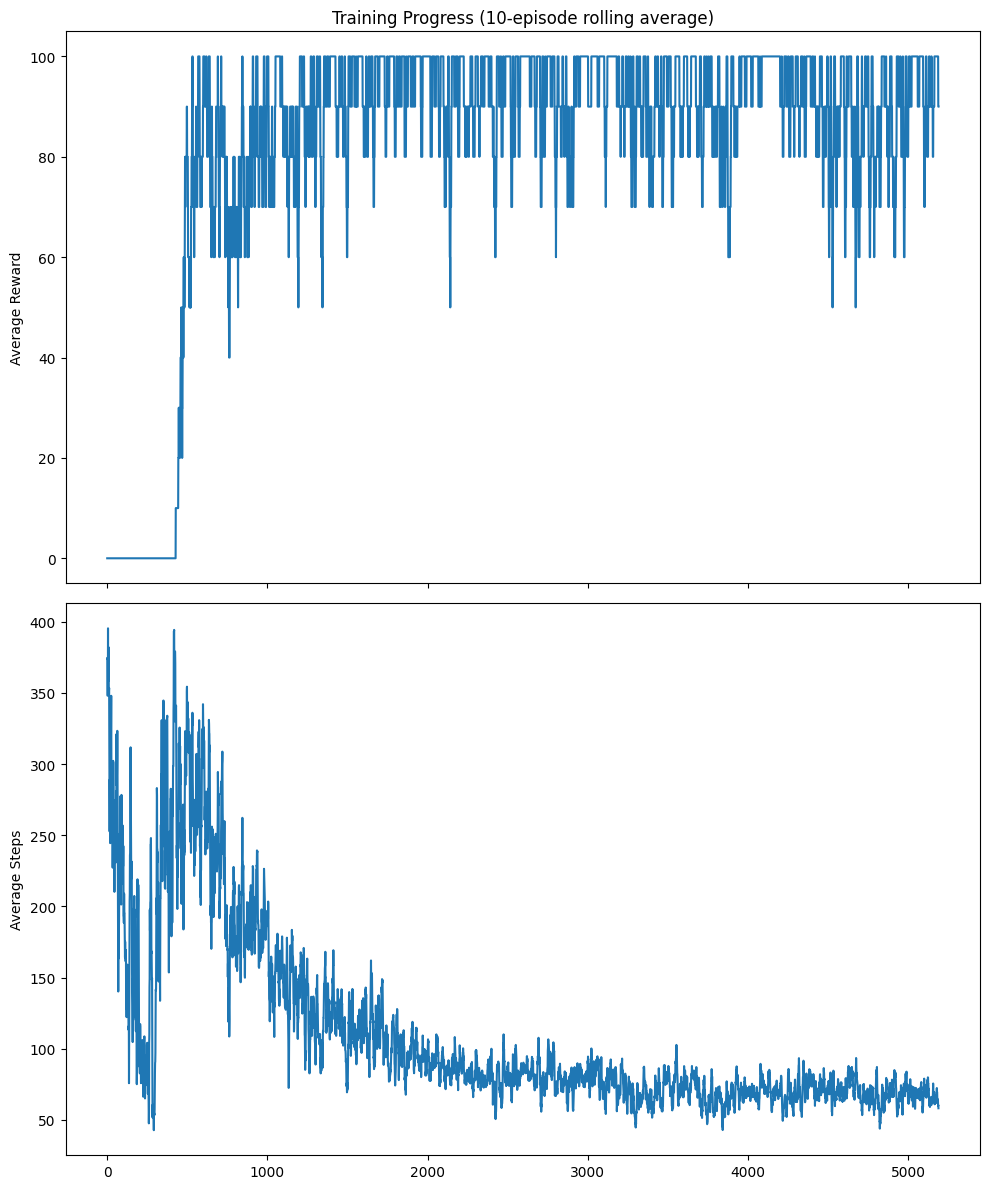

In [3]:
import matplotlib.pyplot as plt

# Calculate rolling averages
window_size = 10
rolling_rewards = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
rolling_steps = np.convolve(steps_history, np.ones(window_size)/window_size, mode='valid')
rolling_success = np.convolve([1 if s else 0 for s in success_history], np.ones(window_size)/window_size, mode='valid') * 100

# Create the plots
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Plot rewards
ax1.plot(rolling_rewards)
ax1.set_ylabel('Average Reward')
ax1.set_title('Training Progress (10-episode rolling average)')

# Plot steps
ax2.plot(rolling_steps)
ax2.set_ylabel('Average Steps')

# Plot success rate
#ax3.plot(rolling_success)
#ax3.set_ylabel('Success Rate (%)')
#ax3.set_xlabel('Episode')

plt.tight_layout()
plt.show()

## **4) Test of the model (with the last and the best models)**

In [ ]:
# Create test environment
test_env = SailingEnv(**get_wind_scenario('training_3'))

# Test parameters
num_test_episodes = 50
max_steps = 500
num_crash = 0
average_step = []
print("Testing the trained agent on 5 new episodes...")
# Testing loop
for episode in range(num_test_episodes):
    # Reset environment
    observation, info = test_env.reset(seed=8000 + episode)  # Different seeds from training
    
    total_reward = 0
    
    for step in range(max_steps):
        # Select action using learned policy
        action = dqn_agent.act(observation, training=False)
        observation, reward, done, truncated, info = test_env.step(action)
        
        total_reward += reward
        
        # Break if episode is done
        if done or truncated:
            is_stuck = info.get('is_stuck', False)
            if is_stuck:
                print(f"Episode {episode+1}: CRASH dans l'île à l'étape {step+1}")
                num_crash += 1
            elif done:
                print(f"Episode {episode+1}: VICTOIRE (Bouée touchée) à l'étape {step+1}")
            else:
                print(f"Episode {episode+1}: Temps expiré (Truncated)")
            break
    average_step.append(step)    
    print(f"Test Episode {episode+1}: Steps={step+1}, Reward={total_reward}, " +
          f"Position={info['position']}, Goal reached={done}")
print(f"Le nombre de crash est {num_crash}")
print(f"average step : {np.mean(np.array(average_step))}")

Testing the trained agent on 5 new episodes...
Episode 1: VICTOIRE (Bouée touchée) à l'étape 47
Test Episode 1: Steps=47, Reward=100.0, Position=[ 63 127], Goal reached=True
Episode 2: VICTOIRE (Bouée touchée) à l'étape 49
Test Episode 2: Steps=49, Reward=100.0, Position=[ 63 127], Goal reached=True
Episode 3: VICTOIRE (Bouée touchée) à l'étape 44
Test Episode 3: Steps=44, Reward=100.0, Position=[ 63 126], Goal reached=True
Episode 4: VICTOIRE (Bouée touchée) à l'étape 50
Test Episode 4: Steps=50, Reward=100.0, Position=[ 63 127], Goal reached=True
Episode 5: VICTOIRE (Bouée touchée) à l'étape 44
Test Episode 5: Steps=44, Reward=100.0, Position=[ 63 126], Goal reached=True
Episode 6: VICTOIRE (Bouée touchée) à l'étape 52
Test Episode 6: Steps=52, Reward=100.0, Position=[ 63 127], Goal reached=True
Episode 7: VICTOIRE (Bouée touchée) à l'étape 46
Test Episode 7: Steps=46, Reward=100.0, Position=[ 63 126], Goal reached=True
Episode 8: VICTOIRE (Bouée touchée) à l'étape 49
Test Episode 8:

In [12]:
# Turn off exploration for evaluation
dqn_agent = DQNAgent(hidden_size_1=64, hidden_size_2=64, memory_buffer = 25000, learning_rate=0.0005, discount_factor=0.97, exploration_rate=0)
dqn_agent.load("best_sailing_model_test_1.pkl")

# Create test environment
test_env = SailingEnv(**get_wind_scenario('training_3'))

# Test parameters
num_test_episodes = 50
max_steps = 500
num_crash = 0
average_step = []
print("Testing the trained agent on 5 new episodes...")
# Testing loop
for episode in range(num_test_episodes):
    # Reset environment
    observation, info = test_env.reset(seed=8000 + episode)  # Different seeds from training
    
    total_reward = 0
    
    for step in range(max_steps):
        # Select action using learned policy
        action = dqn_agent.act(observation, training=False)
        observation, reward, done, truncated, info = test_env.step(action)
        
        total_reward += reward
        
        # Break if episode is done
        if done or truncated:
            is_stuck = info.get('is_stuck', False)
            if is_stuck:
                print(f"Episode {episode+1}: CRASH dans l'île à l'étape {step+1}")
                num_crash += 1
            elif done:
                print(f"Episode {episode+1}: VICTOIRE (Bouée touchée) à l'étape {step+1}")
            else:
                print(f"Episode {episode+1}: Temps expiré (Truncated)")
            break

    average_step.append(step)
    print(f"Test Episode {episode+1}: Steps={step+1}, Reward={total_reward}, " +
          f"Position={info['position']}, Goal reached={done}")
    print(f"Le nombre de crash est {num_crash}")
    print(f"average step : {np.mean(np.array(average_step))}")

Testing the trained agent on 5 new episodes...
Episode 1: VICTOIRE (Bouée touchée) à l'étape 47
Test Episode 1: Steps=47, Reward=100.0, Position=[ 63 127], Goal reached=True
Le nombre de crash est 0
average step : 46.0
Episode 2: VICTOIRE (Bouée touchée) à l'étape 45
Test Episode 2: Steps=45, Reward=100.0, Position=[ 63 127], Goal reached=True
Le nombre de crash est 0
average step : 45.0
Episode 3: VICTOIRE (Bouée touchée) à l'étape 44
Test Episode 3: Steps=44, Reward=100.0, Position=[ 64 126], Goal reached=True
Le nombre de crash est 0
average step : 44.333333333333336
Episode 4: VICTOIRE (Bouée touchée) à l'étape 45
Test Episode 4: Steps=45, Reward=100.0, Position=[ 63 127], Goal reached=True
Le nombre de crash est 0
average step : 44.25
Episode 5: VICTOIRE (Bouée touchée) à l'étape 45
Test Episode 5: Steps=45, Reward=100.0, Position=[ 64 127], Goal reached=True
Le nombre de crash est 0
average step : 44.2
Episode 6: VICTOIRE (Bouée touchée) à l'étape 45
Test Episode 6: Steps=45, Rew

We therefore obtained a score of 44.38 in training on new seeds. We also managed to achieve a score of 43.72 using a learning rate that evolves over time.

The unique change was :"    
initial_lr = 5e-4
final_lr = 5e-5 
lr = final_lr + (initial_lr - final_lr) * np.exp(-episode / 1800)
dqn_agent.policy_net.learning_rate = lr
dqn_agent.target_net.learning_rate = lr
"
in each episode. 


These two models gave very similar results in testing: 77.34 and 77.04. That's why we present only on of them.

However, we specify that there is a lot of randomness in training and therefore the same training loop does not always give the same results even when fixing the seeds; this is why we have kept here only the best results (the weights being recorded and found on codabench, we have a final version of these models and reusable).

## **5) Save the model in the good format**

In [13]:
# Import the utility function for saving DQN agents
from src.utils.agent_utils import save_dqn_agent

# Save our trained agent
save_dqn_agent(
    agent=dqn_agent,
    output_path="/home/onyxia/work/fork_stable_v2_RL_sailing_challenge/src/agents/best_agent_best_model_2.py"
)

Agent saved to /home/onyxia/work/fork_stable_v2_RL_sailing_challenge/src/agents/best_agent_best_model_2.py


## **6) Download the model**

In [10]:
import zipfile
import os

AGENT_FILE = "/home/onyxia/work/fork_stable_v2_RL_sailing_challenge/src/agents/best_agent_best_model.py"
OUTPUT_ZIP = "../reward_best_agent_best_model.zip"
if not os.path.exists(AGENT_FILE):
    print(f"Agent file not found: {AGENT_FILE}")
else:
    # Read the agent code and patch the import for Codabench
    with open(AGENT_FILE, "r") as f:
        code = f.read()

    # Replace local import with Codabench import
    code = code.replace(
        "from agents.base_agent import BaseAgent",
        "from evaluator.base_agent import BaseAgent",
    )

    # Write the submission zip with the .py file at the root
    with zipfile.ZipFile(OUTPUT_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
        zf.writestr("my_agent.py", code)

    print(f"Created {OUTPUT_ZIP}")
    print(f"Contents:")
    with zipfile.ZipFile(OUTPUT_ZIP, "r") as zf:
        for info in zf.infolist():
            print(f"  {info.filename} ({info.file_size} bytes)")

Created ../reward_best_agent_best_model.zip
Contents:
  my_agent.py (134671 bytes)
